---
title: Normalization 
author: Andrei Akopian
date: 2026-03-24
format:
  html:
    code-fold: true
    code-summary: "Show the code"
  pdf:
    code-overflow: wrap
    echo: false
    output: true
---

This notebook describes and covers several normalization methods (for classical models), and why those normalizations might be applicable to our datasets.

Normalizations covered:
- $L_1$ normalization and $L_2$ normalization
- Z-Score Standardization (column wise normalization)

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

In [11]:
# Sys and self defs Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[1]
sys.path.append(str(github_root))

from src.utils import helper_functions

In [12]:
ATMO_DATA = "../../data/isprs_26_only_vza_rows.csv"
LAB_DATA = "../../data/useful_columns_data.csv"

In [13]:
df = helper_functions.open_file(LAB_DATA)
fractions, nr900to1690_raw = helper_functions.take_subset(df,start=900,end=1690)

# $L_1$ and $L_2$ normalizations
Surprisingly $L_1$ and $L_2$ row wise normalizations (which essentially normalize the quantity of light in a spectra), both produce similar results that improve most classical models by a slight but significant amount.

On the raw dataset, [KNN model](../classicalml/knn/knn.ipynb) prefers cosine definition of distances, rather than Euclidian. In fact, the Euclidian distance produces results as much as $0.10$ $R^2$ "points" worse than the cosine definition. Regradless of the statistical formality of these statements, normalization certainly has room to work here.

### $L_1$ rowise normalization

The below histogram shows that the sums of reflectances may vary by as much as $4\times$ between samples in the dataset.

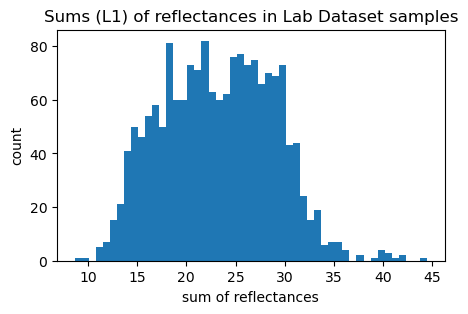

In [16]:
sums = nr900to1690_raw.sum(axis=1).to_numpy()
helper_functions.simple_histogram(sums, title="Sums (L1) of reflectances in Lab Dataset samples", bins=50, x_label="sum of reflectances", y_label="count")

In [17]:
# L1 norm
dataset = nr900to1690_raw
norms = dataset.sum(axis=1).to_numpy()
print(f"L1 before normalization: min={norms.min()} max={norms.max()}")
normalized_dataset = dataset.copy().to_numpy() / norms[:, np.newaxis]
post_norms = normalized_dataset.sum(axis=1)
print(f"L1 after normalization: min={post_norms.min()} max={post_norms.max()}")
nr900to1690 = normalized_dataset

L1 before normalization: min=8.6551167051 max=44.43919789800001
L1 after normalization: min=0.9999999999999988 max=1.0000000000000009


### $L_2$ normalization

Here is the similar code for the $L_2$ normalization. Observe that prior to normalization, the $L_2$ reflectence norms look similar to $L_1$ reflectence sums.

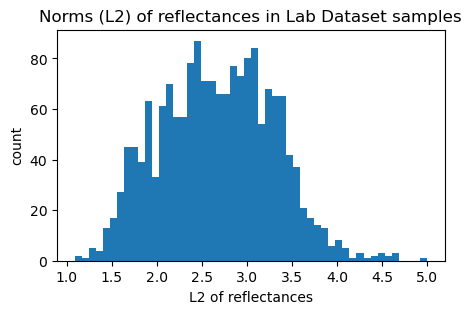

In [23]:
norms = np.sqrt(np.square(dataset).sum(axis=1)).to_numpy()
helper_functions.simple_histogram(norms, title="Norms (L2) of reflectances in Lab Dataset samples", bins=50, x_label="L2 of reflectances", y_label="count")

In [21]:
# L2 norm
dataset = nr900to1690_raw
norms = np.sqrt(np.square(dataset).sum(axis=1)).to_numpy()
print(f"L1 before normalization: min={norms.min()} max={norms.max()}")
normalized_dataset = dataset.copy().to_numpy() / norms[:, np.newaxis]
post_norms = np.sqrt(np.square(normalized_dataset).sum(axis=1))
print(f"L1 after normalization: min={post_norms.min()} max={post_norms.max()}")
nr900to1690 = normalized_dataset

L1 before normalization: min=1.0853925339623511 max=4.995320587151579
L1 after normalization: min=0.9999999999999994 max=1.0000000000000007


# Z-score standarization of wavelengths
Where previously we performed row-wise normalization, we will now be performing column-wise normalization.

During the dataset characterization, we observed that individual wavelengths are distributed in a symetric cluster with a peak in the middle, so Z-score normalization (likely performed automatically by SciKit learn and other libraries we are using), is not entirely wrong.
Here is copy of the relevant results from [Dataset Characterization](../characterization/dataset_characterization.ipynb).
Note that at exactly 1390nm the distribution switches to bimodal (2 peaks). This is concerning and was described as an "anomaly" in the Dataset Characterization. But we will just assume it doesn't affect our results too much.

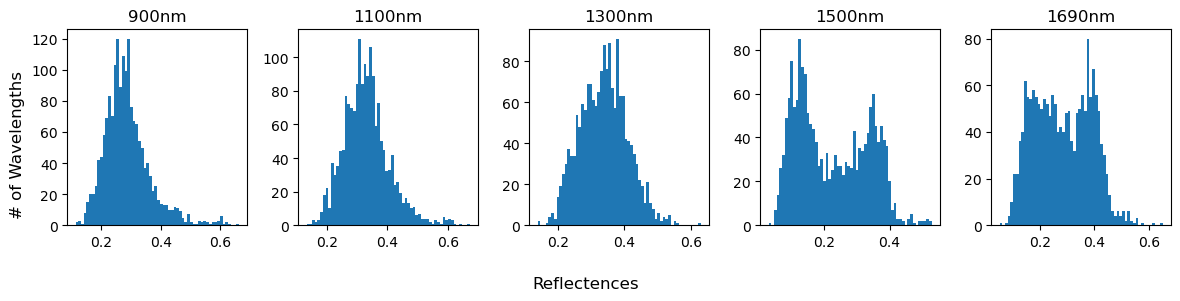

In [36]:
wavelengths = ["900", "1100", "1300", "1500", "1690"]
n_plots = len(wavelengths)
fig, axs = plt.subplots(1, n_plots, figsize=(12, 3))

fig.supxlabel("Reflectences")
fig.supylabel("# of Wavelengths")

for i, s in enumerate(wavelengths):
    axs[i].hist(nr900to1690_raw[s],bins=60)
    axs[i].set_title(s+'nm')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# Sanity Checks: effects of $L_1/L_2$ on each other and Z-scores and vice versa.

## Effect of $L_1$ on $L_2$ and Z-score standarization

In [59]:
# L1 norm
dataset = nr900to1690_raw
norms = dataset.sum(axis=1).to_numpy()
print(f"L1 before normalization: min={norms.min()} max={norms.max()}")
normalized_dataset = dataset.copy().to_numpy() / norms[:, np.newaxis]
post_norms = normalized_dataset.sum(axis=1)
print(f"L1 after normalization: min={post_norms.min()} max={post_norms.max()}")
nr900to1690_l1 = normalized_dataset

L1 before normalization: min=8.6551167051 max=44.43919789800001
L1 after normalization: min=0.9999999999999988 max=1.0000000000000009


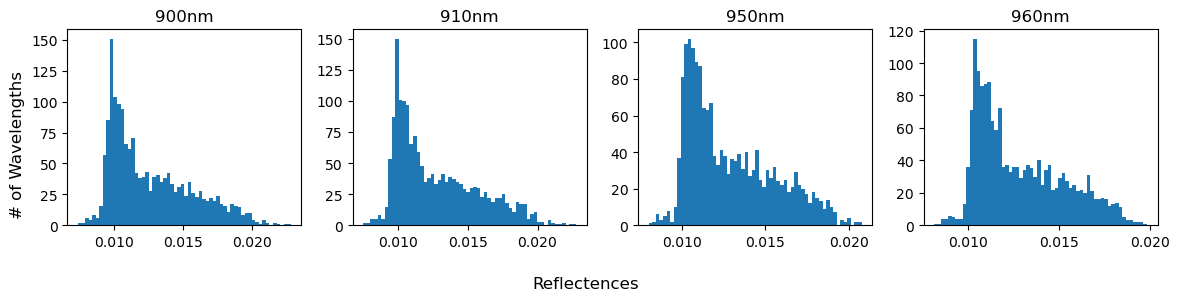

In [60]:
dataset = nr900to1690_l1

columns = nr900to1690_raw.columns
wavelengths = [0, 1, 5, 6]
n_plots = len(wavelengths)
fig, axs = plt.subplots(1, n_plots, figsize=(12, 3))

fig.supxlabel("Reflectences")
fig.supylabel("# of Wavelengths")

for i, w in enumerate(wavelengths):
    axs[i].hist(dataset[:,w],bins=60)
    axs[i].set_title(columns[w]+'nm')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

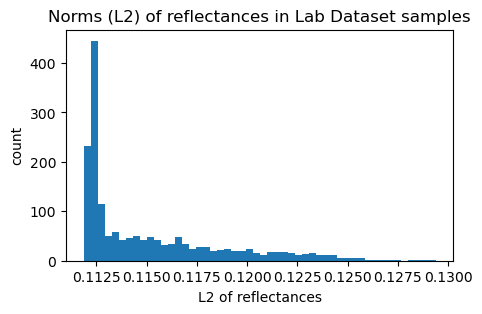

In [62]:
norms = np.sqrt(np.square(nr900to1690_l1).sum(axis=1))
helper_functions.simple_histogram(norms, title="Norms (L2) of reflectances in Lab Dataset samples", bins=50, x_label="L2 of reflectances", y_label="count")

## Effect of $L_2$ on $L_1$ and Z-score standarization

In [64]:
# L2 norm
dataset = nr900to1690_raw
norms = np.sqrt(np.square(dataset).sum(axis=1)).to_numpy()
print(f"L1 before normalization: min={norms.min()} max={norms.max()}")
normalized_dataset = dataset.copy().to_numpy() / norms[:, np.newaxis]
post_norms = np.sqrt(np.square(normalized_dataset).sum(axis=1))
print(f"L1 after normalization: min={post_norms.min()} max={post_norms.max()}")
nr900to1690_l2 = normalized_dataset

L1 before normalization: min=1.0853925339623511 max=4.995320587151579
L1 after normalization: min=0.9999999999999994 max=1.0000000000000007


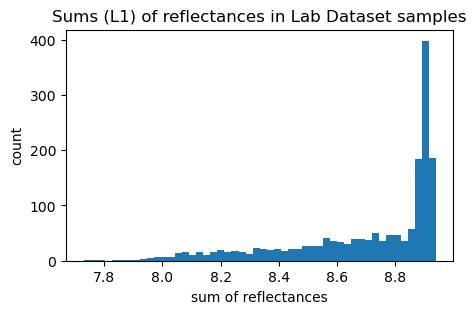

In [65]:
sums = nr900to1690_l2.sum(axis=1)
helper_functions.simple_histogram(sums, title="Sums (L1) of reflectances in Lab Dataset samples", bins=50, x_label="sum of reflectances", y_label="count")

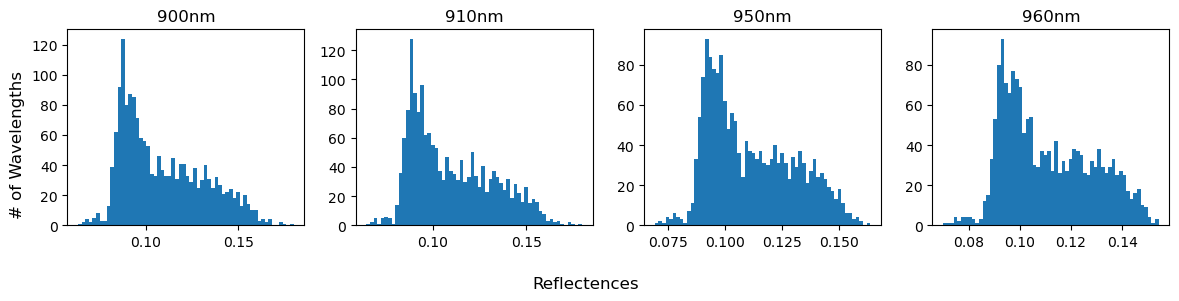

In [66]:
dataset = nr900to1690_l2

columns = nr900to1690_raw.columns
wavelengths = [0, 1, 5, 6]
n_plots = len(wavelengths)
fig, axs = plt.subplots(1, n_plots, figsize=(12, 3))

fig.supxlabel("Reflectences")
fig.supylabel("# of Wavelengths")

for i, w in enumerate(wavelengths):
    axs[i].hist(dataset[:,w],bins=60)
    axs[i].set_title(columns[w]+'nm')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

### Effect of Z-score standarization on $L_2$ and $L_1$

In [68]:
zscored_df = nr900to1690_raw.copy()
for column in zscored_df.columns:
    zscored_df[column] = zscore(zscored_df[column])

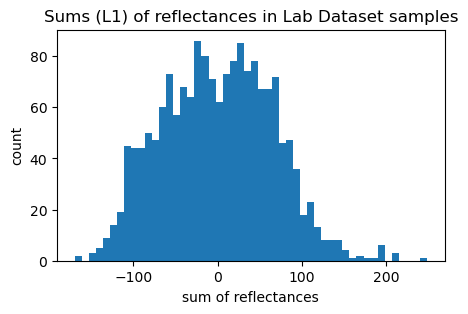

In [70]:
sums = zscored_df.sum(axis=1)
helper_functions.simple_histogram(sums, title="Sums (L1) of reflectances in Lab Dataset samples", bins=50, x_label="sum of reflectances", y_label="count")

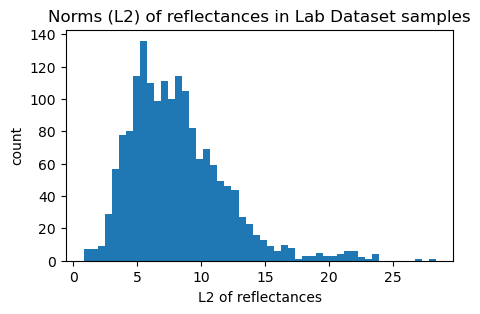

In [71]:
norms = np.sqrt(np.square(zscored_df).sum(axis=1)).to_numpy()
helper_functions.simple_histogram(norms, title="Norms (L2) of reflectances in Lab Dataset samples", bins=50, x_label="L2 of reflectances", y_label="count")

# Atmo Data

In atmospheric data, normalization is necessary, because otherwise wavelengths are very strongly interally correlated.

Below are duplicates of code from [Dataset Characterization](../characterization/dataset_characterization.ipynb), and then the same but after normalizing.

In [80]:
df = helper_functions.open_file(ATMO_DATA)
fractions, at900to1690_raw = helper_functions.take_subset(df,start=900,end=1690)
vza = df["VZA"]

In [81]:
correlations = []
dataset = at900to1690_raw
for c1 in dataset.columns:
    cors = []
    for c2 in dataset.columns:
        slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(dataset[c1], dataset[c2])
        cors.append(r_value**2)
    correlations.append(cors)

Observe that most wavelengths are strongly correlated with each other. The reason for this, is a set of outliers, which we will describe in a moment.

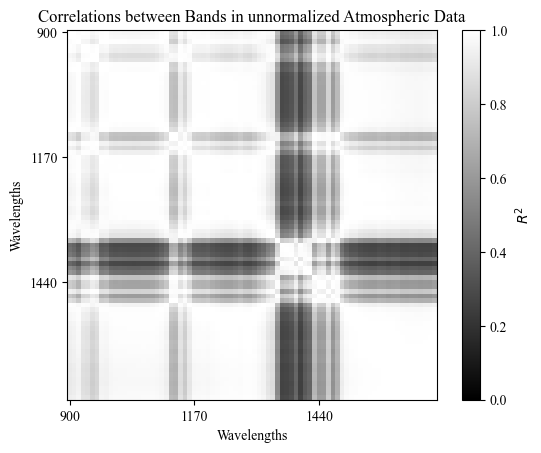

In [82]:
fig, ax = plt.subplots()

img = ax.imshow(correlations, vmin=0, cmap='gray')

ax.set_title("Correlations between Bands in unnormalized Atmospheric Data")
ax.set_xlabel("Wavelengths")
ax.set_ylabel("Wavelengths")
tick_locations = np.arange(0, dataset.shape[1], 27)
tick_labels = [dataset.columns[i] for i in tick_locations]
ax.set_xticks(tick_locations, tick_labels)
ax.set_yticks(tick_locations, tick_labels)

cbar = fig.colorbar(img, ax=ax, label='$R^2$')
plt.savefig("atmo_data_correlations.svg", format="svg")
plt.show()

Here is a graph shoving relationship between NPV, VZA (visibility), and reflectance in atmospheric data. YOu can see the outlier sets (which unusually high reflectances), and the miniscule variations in the reflectances of the majority of datapoints.

Under these circumstances, Linear Regression and other methods will struggle to produce good models. (and in fact they don't.)

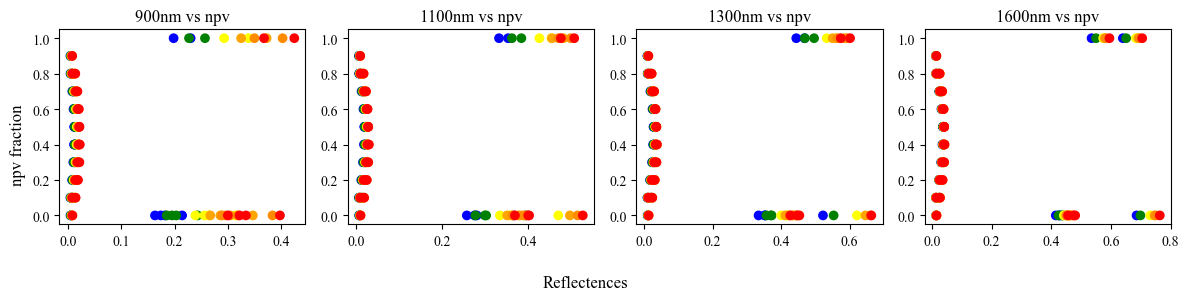

In [ ]:
vza_color_map = {
    0.0 : "blue",
    10.0 : "green",
    20.0 : "yellow",
    25.0 : "orange",
    30.0 : "darkorange",
    40.0 : "red",
}
wavelengths = ["900", "1100", "1300", "1600"]
n_plots = len(wavelengths)
plt.rcParams["font.family"] = "Times New Roman"
fig, axs = plt.subplots(1, n_plots, figsize=(3*n_plots, 3))
fig.supxlabel("Reflectences")
fig.supylabel("npv fraction")

for i, wavelength in enumerate(wavelengths):
    axs[i].scatter(at900to1690[wavelength].to_numpy().reshape(-1, 1), fractions["npv_fraction"], c=[
        vza_color_map[v] for v in vza
    ])
    axs[i].set_title(f"{wavelength}nm vs npv")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## $L_2$ normalization of atmospheric data 

TODO finish writing this and get the code to work.

In [85]:
# L2 norm
dataset = at900to1690_raw
norms = np.sqrt(np.square(dataset).sum(axis=1)).to_numpy()
print(f"L1 before normalization: min={norms.min()} max={norms.max()}")
normalized_dataset = dataset.copy().to_numpy() / norms[:, np.newaxis]
post_norms = np.sqrt(np.square(normalized_dataset).sum(axis=1))
print(f"L1 after normalization: min={post_norms.min()} max={post_norms.max()}")
at900to1690 = normalized_dataset

L1 before normalization: min=0.07422868006799167 max=5.547629854271101
L1 after normalization: min=0.9999999999999996 max=1.0000000000000002


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

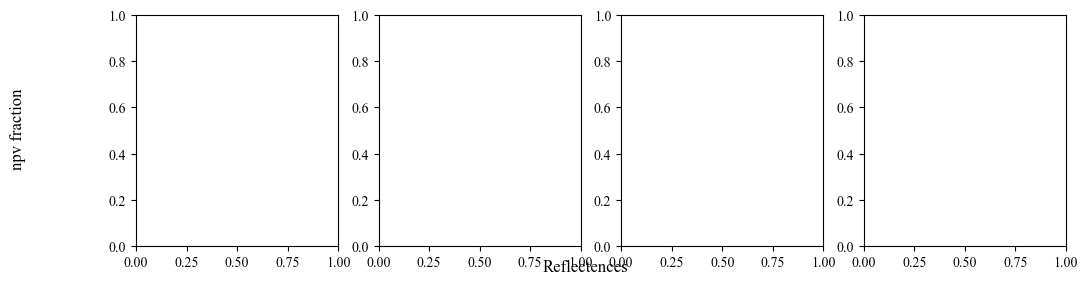

In [ ]:
vza_color_map = {
    0.0 : "blue",
    10.0 : "green",
    20.0 : "yellow",
    25.0 : "orange",
    30.0 : "darkorange",
    40.0 : "red",
}
wavelengths = ["900", "1100", "1300", "1600"]
n_plots = len(wavelengths)
plt.rcParams["font.family"] = "Times New Roman"
fig, axs = plt.subplots(1, n_plots, figsize=(3*n_plots, 3))
fig.supxlabel("Reflectences")
fig.supylabel("npv fraction")

for i, w in enumerate(wavelengths):
    axs[i].scatter(at900to1690[wavelength], fractions["npv_fraction"], c=[
        vza_color_map[v] for v in vza
    ])
    axs[i].set_title(f"{wavelength}nm vs npv")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [89]:
correlations = []
dataset = at900to1690
for c1 in range(at900to1690.shape[1]):
    cors = []
    for c2 in range(at900to1690.shape[1]):
        slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(dataset[c1], dataset[c2])
        cors.append(r_value**2)
    correlations.append(cors)

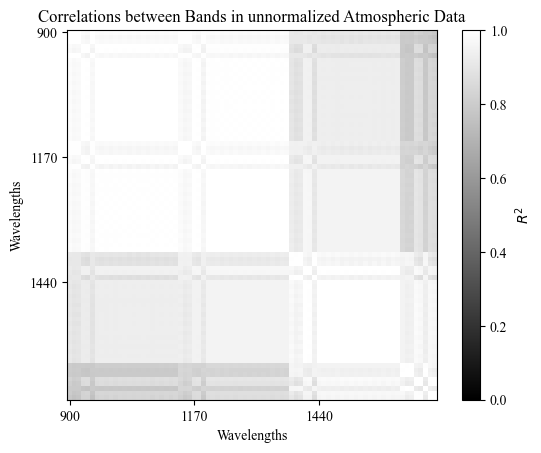

In [91]:
fig, ax = plt.subplots()

img = ax.imshow(correlations, vmin=0, cmap='gray')

ax.set_title("Correlations between Bands in unnormalized Atmospheric Data")
ax.set_xlabel("Wavelengths")
ax.set_ylabel("Wavelengths")
tick_locations = np.arange(0, dataset.shape[1], 27)
ax.set_xticks(tick_locations, tick_labels)
ax.set_yticks(tick_locations, tick_labels)

cbar = fig.colorbar(img, ax=ax, label='$R^2$')
plt.savefig("atmo_data_correlations.svg", format="svg")
plt.show()